In [44]:
import os
import random
from pathlib import Path
from datasets import load_dataset
import sentencepiece as spm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import sacrebleu

In [2]:
ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")

# Create tokens

In [3]:
def extract_texts(dataset, split, n_samples=None):
    src = []
    tgt = []
    it = dataset[split]
    if n_samples:
        it = it.select(range(min(n_samples, len(it))))
    for ex in it:
        tr = ex["translation"]
        pl = tr.get("pl")
        en = tr.get("en")
        if pl and en:
            src.append(pl.strip())
            tgt.append(en.strip())
    return src, tgt


n_samples=50000 # subset for quicker train
train_src, train_tgt = extract_texts(ds, "train", n_samples=n_samples)
val_src, val_tgt = extract_texts(ds, "validation")
test_src, test_tgt = extract_texts(ds, "test")

print("Train pairs:", len(train_src))
print("Validation pairs:", len(val_src))
print("Test pairs:", len(test_src))

Train pairs: 50000
Validation pairs: 2000
Test pairs: 2000


In [45]:
data_dir = Path("./opus_data")
spm_model_prefix = data_dir / "spm"
vocab_size = 8000
max_src_len = 128
max_tgt_len = 128
batch_size = 128
seed = 42

os.makedirs(data_dir, exist_ok=True)
random.seed(seed)

In [5]:
train_txt = data_dir / "spm_train.txt"
with open(train_txt, "w", encoding="utf-8") as fout:
    for s in train_src:
        fout.write(s.replace("\n", " ") + "\n")
    for t in train_tgt:
        fout.write(t.replace("\n", " ") + "\n")

In [8]:
spm_args = (
    f"--input={str(train_txt)} "
    f"--model_prefix={str(spm_model_prefix)} "
    f"--vocab_size={vocab_size} "
    f"--model_type=bpe "
    f"--character_coverage=1.0 "
    f"--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3 "
    f"--pad_piece=<pad> --unk_piece=<unk> --bos_piece=<s> --eos_piece=</s>"
)
spm.SentencePieceTrainer.Train(spm_args)

In [15]:
sp = spm.SentencePieceProcessor()
sp.Load(str(spm_model_prefix) + ".model")

print("Vocab size:", sp.GetPieceSize())
print("Sample encoding:", sp.EncodeAsIds("To jest mój dom."))

pad_id = sp.PieceToId("<pad>")
unk_id = sp.PieceToId("<unk>")
sos_id = sp.PieceToId("<s>")
eos_id = sp.PieceToId("</s>")
print("pad,unk,sos,eos ids:", pad_id, unk_id, sos_id, eos_id)

Vocab size: 8000
Sample encoding: [224, 138, 1460, 866, 7673]
pad,unk,sos,eos ids: 0 1 2 3


In [17]:
def encode_sentence(s: str, max_len: int):
    ids = sp.EncodeAsIds(s)
    # truncate + reserve space for start-of-seq and end-of-seq
    if len(ids) > max_len:
        ids = ids[:max_len]
    return ids

class PlEnOpusDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, max_src_len=128, max_tgt_len=128):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src = self.src_texts[idx]
        tgt = self.tgt_texts[idx]
        src_ids = encode_sentence(src, self.max_src_len)
        tgt_ids = encode_sentence(tgt, self.max_tgt_len - 1)
        decoder_input = [sos_id] + tgt_ids
        decoder_target = tgt_ids + [eos_id]
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(decoder_input, dtype=torch.long), torch.tensor(decoder_target, dtype=torch.long)

In [18]:
def collate_fn(batch):
    src_list, dec_in_list, dec_tgt_list = zip(*batch)
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=pad_id)
    dec_in_padded = pad_sequence(dec_in_list, batch_first=True, padding_value=pad_id)
    dec_tgt_padded = pad_sequence(dec_tgt_list, batch_first=True, padding_value=pad_id)

    src_lens = torch.tensor([len(x) for x in src_list], dtype=torch.long)
    dec_lens = torch.tensor([len(x) for x in dec_in_list], dtype=torch.long)

    return {
        "src_ids": src_padded,
        "src_lens": src_lens,
        "dec_input_ids": dec_in_padded,
        "dec_target_ids": dec_tgt_padded,
        "dec_lens": dec_lens
    }

train_dataset = PlEnOpusDataset(train_src, train_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)
val_dataset = PlEnOpusDataset(val_src, val_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)
test_dataset = PlEnOpusDataset(test_src, test_tgt, max_src_len=max_src_len, max_tgt_len=max_tgt_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [19]:
batch = next(iter(train_loader))
print("src_ids shape:", batch["src_ids"].shape)
print("dec_input_ids shape:", batch["dec_input_ids"].shape)
print("dec_target_ids shape:", batch["dec_target_ids"].shape)
print("src_lens:", batch["src_lens"][:8])
print("dec_lens:", batch["dec_lens"][:8])

def decode_ids(ids):
    return sp.DecodeIds(ids.tolist())

print("Example src text (reconstructed):", decode_ids(batch["src_ids"][0][batch["src_ids"][0] != pad_id]))
print("Example decoder input (reconstructed):", decode_ids(batch["dec_input_ids"][0][batch["dec_input_ids"][0] != pad_id]))
print("Example decoder target (reconstructed):", decode_ids(batch["dec_target_ids"][0][batch["dec_target_ids"][0] != pad_id]))

src_ids shape: torch.Size([32, 105])
dec_input_ids shape: torch.Size([32, 80])
dec_target_ids shape: torch.Size([32, 80])
src_lens: tensor([ 8, 11,  9,  9,  3, 24,  7, 11])
dec_lens: tensor([ 8, 14, 13, 11,  3, 19, 13, 13])
Example src text (reconstructed): Umarł w moich ramionach.
Example decoder input (reconstructed): He died in my arms.
Example decoder target (reconstructed): He died in my arms.


# Train utils

In [46]:
def compute_bleu(references, hypotheses):
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu.score

In [47]:
def train_epoch(model, dataloader, optimizer, device, clip=2.0):
    model.train()
    total_loss = 0.0
    total_tokens = 0
    for batch in tqdm(dataloader, desc="train"):
        src = batch["src_ids"].to(device)
        dec_in = batch["dec_input_ids"].to(device)
        dec_tgt = batch["dec_target_ids"].to(device)
        optimizer.zero_grad()
        logits = model(src, dec_in)
        B, T, V = logits.size()
        logits_flat = logits.view(B * T, V)
        targets_flat = dec_tgt.view(B * T)
        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
        optimizer.step()

        non_pad = (targets_flat != pad_id).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad

    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    return avg_loss

In [48]:
def evaluate(model, dataloader, device, max_decode_len=80):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    preds = []
    refs = []
    with torch.no_grad():
        for i, batch in enumerate(tqdm(dataloader, desc="eval")):
            src = batch["src_ids"].to(device)
            dec_in = batch["dec_input_ids"].to(device)
            dec_tgt = batch["dec_target_ids"].to(device)
            logits = model(src, dec_in)
            B, T, V = logits.size()
            logits_flat = logits.view(B*T, V)
            targets_flat = dec_tgt.view(B*T)
            loss = criterion(logits_flat, targets_flat)

            non_pad = (targets_flat != pad_id).sum().item()
            total_loss += loss.item() * non_pad
            total_tokens += non_pad

            preds_ids = model.greedy_decode(src, max_len=max_decode_len, device=device)
            for b in range(preds_ids.size(0)):
                pred_seq = preds_ids[b]
                # cut at end-of-seq token
                pred_list = pred_seq.cpu().tolist()
                if eos_id in pred_list:
                    idx = pred_list.index(eos_id)
                    pred_list = pred_list[:idx]
                hyp = sp.DecodeIds([int(x) for x in pred_list])
                preds.append(hyp)

            for b in range(dec_tgt.size(0)):
                ref_seq = dec_tgt[b].cpu().tolist()
                if eos_id in ref_seq:
                    idx = ref_seq.index(eos_id)
                    ref_seq = ref_seq[:idx]
                ref_text = sp.DecodeIds([int(x) for x in ref_seq if x != pad_id])
                refs.append(ref_text)

    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0.0
    n = min(len(refs), len(preds))
    if n == 0:
        bleu = 0.0
    else:
        bleu = compute_bleu(refs[:n], preds[:n])
    return avg_loss, bleu

In [57]:
def train_loop(model, n_epochs, train_loader, val_loader, optimizer, device, ckpt_dir, patience):
    best_val_bleu = -1.0
    history = {"train_loss": [], "val_loss": [], "val_bleu": []}

    no_improve = 0

    for epoch in range(1, n_epochs+1):
        print(f"\n=== Epoch {epoch}/{n_epochs} ===")
        train_loss = train_epoch(model, train_loader, optimizer, device, clip=2.0)
        val_loss, val_bleu = evaluate(model, val_loader, device, max_decode_len=80)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_bleu"].append(val_bleu)

        print(f"Epoch {epoch} Train loss={train_loss:.4f}  Val loss={val_loss:.4f}  Val BLEU={val_bleu:.3f}")

        if val_bleu > best_val_bleu:
            best_val_bleu = val_bleu
            no_improve = 0
            ckpt_path = ckpt_dir / f"best_seq2seq_epoch{epoch}_bleu{val_bleu:.2f}.pt"
            torch.save({
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "epoch": epoch,
                "val_bleu": val_bleu,
                "vocab_size": vocab_size,
            }, ckpt_path)
            print("Saved best checkpoint:", ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print("No improvement for", patience, "epochs. Early stopping.")
                break

    return history, ckpt_path

In [58]:
def plot_loss_bleu_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, history["val_bleu"], label="val_bleu")
    plt.xlabel("Epoch")
    plt.ylabel("BLEU")
    plt.legend()
    plt.grid(True)
    plt.show()

In [49]:
def select_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


device = select_device()

# No Attention Encoder-Decoder

In [50]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0.0)
        self.hidden_size = hidden_size
        self.n_layers = n_layers

    def forward(self, src_ids):
        emb = self.embedding(src_ids)
        outputs, hidden = self.gru(emb)
        return outputs, hidden

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers>1 else 0.0)
        self.output_proj = nn.Linear(hidden_size, vocab_size)

    def forward(self, dec_input_ids, hidden):
        emb = self.embedding(dec_input_ids)
        outputs, hidden = self.gru(emb, hidden)
        logits = self.output_proj(outputs)
        return logits, hidden

class Seq2SeqGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, encoder_layers=1, decoder_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.encoder = EncoderGRU(vocab_size, embed_dim, hidden_size, n_layers=encoder_layers, dropout=dropout, pad_id=pad_id)
        self.decoder = DecoderGRU(vocab_size, embed_dim, hidden_size, n_layers=decoder_layers, dropout=dropout, pad_id=pad_id)
        self.pad_id = pad_id
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

    def forward(self, src_ids, dec_input_ids):
        _, enc_hidden = self.encoder(src_ids)
        logits, _ = self.decoder(dec_input_ids, enc_hidden)
        return logits

    def greedy_decode(self, src_ids, max_len=100, device=None):
        device = device or next(self.parameters()).device
        batch_size = src_ids.size(0)
        _, enc_hidden = self.encoder(src_ids.to(device))
        ys = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
        hidden = enc_hidden
        outputs = []
        for t in range(max_len):
            logits, hidden = self.decoder(ys[:, -1:].to(device), hidden)
            token_logits = logits[:, -1, :]
            next_tokens = token_logits.argmax(dim=-1, keepdim=True)
            outputs.append(next_tokens)
            ys = torch.cat([ys, next_tokens], dim=1)
            if (next_tokens == eos_id).all():
                break

        out = torch.cat(outputs, dim=1)
        return out


In [31]:
vocab_size = sp.GetPieceSize()

model = Seq2SeqGRU(
    vocab_size=vocab_size,
    embed_dim=256,
    hidden_size=512,
    encoder_layers=1,
    decoder_layers=1,
    dropout=0.3,
    pad_id=pad_id
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [35]:
ckpt_dir = Path("seq2seq_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
n_epochs = 10
patience = 3

no_attn_history, no_attn_ckpt_path = train_loop(model, n_epochs, train_loader, val_loader, optimizer, device, ckpt_dir, patience)


=== Epoch 1/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:06,  5.24it/s]


Epoch 1 Train loss=4.7855  Val loss=4.2792  Val BLEU=1.056
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch1_bleu1.06.pt

=== Epoch 2/10 ===


eval:  49%|████▉     | 31/63 [00:04<00:05,  6.25it/s]


Epoch 2 Train loss=3.8477  Val loss=4.0028  Val BLEU=1.941
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch2_bleu1.94.pt

=== Epoch 3/10 ===


...

Epoch 8 Train loss=2.1697  Val loss=4.1543  Val BLEU=3.541
Saved best checkpoint: seq2seq_checkpoints/best_seq2seq_epoch8_bleu3.54.pt

=== Epoch 9/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:05,  5.72it/s]


Epoch 9 Train loss=1.9808  Val loss=4.2833  Val BLEU=3.537

=== Epoch 10/10 ===


eval:  49%|████▉     | 31/63 [00:05<00:05,  5.83it/s]

Epoch 10 Train loss=1.8112  Val loss=4.3807  Val BLEU=3.436


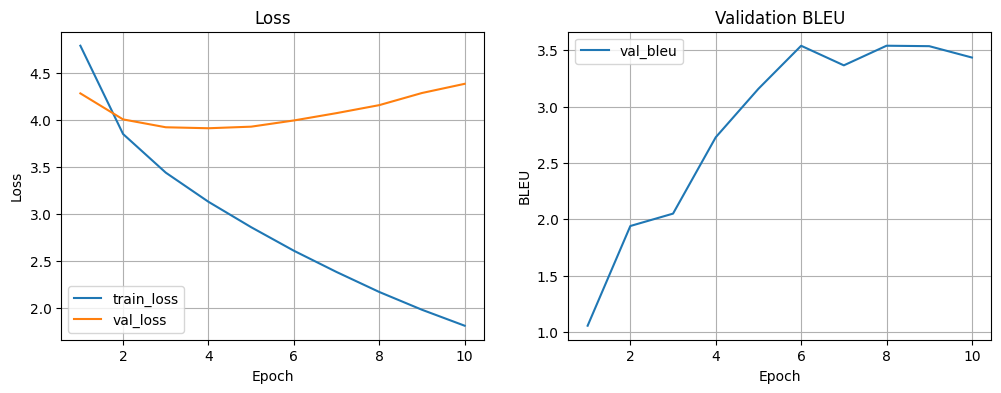

In [36]:
plot_loss_bleu_history(no_attn_history)

In [37]:
# Eval on best checkpoint
best_ckpt = no_attn_ckpt_path
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()
test_loss, test_bleu = evaluate(model, test_loader, device, max_decode_len=80)
print(f"Test loss: {test_loss:.4f}, Test BLEU: {test_bleu:.3f}")

Loading seq2seq_checkpoints/best_seq2seq_epoch8_bleu3.54.pt


eval:  98%|█████████▊| 62/63 [00:10<00:00,  6.07it/s]

Test loss: 4.2356, Test BLEU: 2.754


# Add Attention

In [52]:
class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        dec_hidden = self.Wa(decoder_hidden).unsqueeze(1)
        scores = torch.bmm(dec_hidden, encoder_outputs.transpose(1, 2)).squeeze(1)

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        context = context.squeeze(1)
        return context, attn_weights

In [53]:
class DecoderGRUWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.gru = nn.GRU(embed_dim, hidden_size, num_layers=n_layers, batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.attn = LuongAttention(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output_proj = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, dec_input_ids, hidden, encoder_outputs):
        emb = self.dropout(self.embedding(dec_input_ids))
        outputs = []
        h = hidden
        for t in range(dec_input_ids.size(1)):
            inp = emb[:, t:t+1, :]
            out, h = self.gru(inp, h)
            out = out.squeeze(1)
            context, attn_weights = self.attn(out, encoder_outputs)
            concat_input = torch.cat([out, context], dim=-1)
            out_combined = torch.tanh(self.concat(concat_input))
            logits = self.output_proj(out_combined)
            outputs.append(logits.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)
        return outputs, h


In [54]:
class Seq2SeqGRU_Attn(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, encoder_layers=1, decoder_layers=1, dropout=0.1, pad_id=0):
        super().__init__()
        self.encoder = EncoderGRU(vocab_size, embed_dim, hidden_size, n_layers=encoder_layers, dropout=dropout, pad_id=pad_id)
        self.decoder = DecoderGRUWithAttention(vocab_size, embed_dim, hidden_size, n_layers=decoder_layers, dropout=dropout, pad_id=pad_id)
        self.pad_id = pad_id

    def forward(self, src_ids, dec_input_ids):
        encoder_outputs, enc_hidden = self.encoder(src_ids)
        logits, _ = self.decoder(dec_input_ids, enc_hidden, encoder_outputs)
        return logits

    def greedy_decode(self, src_ids, max_len=100, device=None):
        device = device or next(self.parameters()).device
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src_ids.to(device))
            mask = (src_ids != self.pad_id).to(device)
            batch_size = src_ids.size(0)
            ys = torch.full((batch_size, 1), sos_id, dtype=torch.long, device=device)
            outputs = []
            for _ in range(max_len):
                logits, hidden = self.decoder(ys[:, -1:], hidden, encoder_outputs, mask)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                outputs.append(next_token)
                ys = torch.cat([ys, next_token], dim=1)
                if (next_token == eos_id).all():
                    break
            return torch.cat(outputs, dim=1)


In [55]:
attn_model = Seq2SeqGRU_Attn(
    vocab_size=vocab_size,
    embed_dim=256,
    hidden_size=512,
    dropout=0.3,
    pad_id=pad_id
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = Adam(attn_model.parameters(), lr=1e-3, weight_decay=1e-5)

In [56]:
ckpt_dir = Path("seq2seq_attn_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
n_epochs = 10
patience = 3

attn_history, attn_ckpt_path = train_loop(attn_model, n_epochs, train_loader, val_loader, optimizer, device, ckpt_dir, patience)


=== Epoch 1/10 ===


eval: 100%|██████████| 63/63 [00:13<00:00,  4.67it/s]


Epoch 1 Train loss=4.9462  Val loss=4.4689  Val BLEU=1.263
Saved best checkpoint: seq2seq_attn_checkpoints/best_seq2seq_epoch1_bleu1.26.pt

=== Epoch 2/10 ===


eval: 100%|██████████| 63/63 [00:12<00:00,  5.07it/s]


Epoch 2 Train loss=4.0567  Val loss=4.0703  Val BLEU=2.572
Saved best checkpoint: seq2seq_attn_checkpoints/best_seq2seq_epoch2_bleu2.57.pt

=== Epoch 3/10 ===


...

Epoch 8 Train loss=2.3766  Val loss=3.8621  Val BLEU=5.481

=== Epoch 9/10 ===


eval: 100%|██████████| 63/63 [00:13<00:00,  4.76it/s]


Epoch 9 Train loss=2.2206  Val loss=3.9046  Val BLEU=5.709

=== Epoch 10/10 ===


eval: 100%|██████████| 63/63 [00:13<00:00,  4.57it/s]

Epoch 10 Train loss=2.0788  Val loss=3.9502  Val BLEU=5.366
No improvement for 3 epochs. Early stopping.


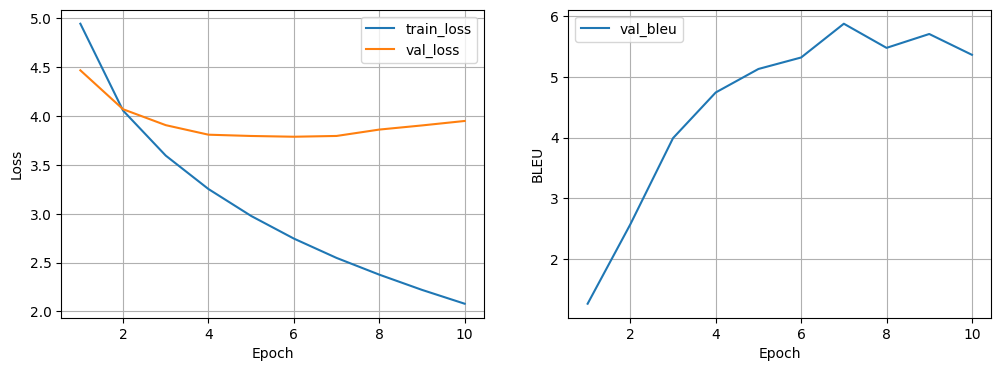

In [60]:
plot_loss_bleu_history(attn_history)

In [62]:
# Eval on best checkpoint
best_ckpt = attn_ckpt_path
ckpt = torch.load(best_ckpt, map_location=device)
attn_model.load_state_dict(ckpt["model_state"])
attn_model.to(device)
attn_model.eval()
test_loss, test_bleu = evaluate(attn_model, test_loader, device, max_decode_len=80)
print(f"Test loss: {test_loss:.4f}, Test BLEU: {test_bleu:.3f}")

eval: 100%|██████████| 63/63 [00:13<00:00,  4.65it/s]


Test loss: 3.8391, Test BLEU: 5.320


# Wnioski
- Różnica w BLEU dla modeli z/bez attencji nie jest duża, ale jest prawie dwukrotna. Pokazuje to, że attencja moźe znacząco polepszyć wyniki.

- Z wykresów widać dopasowanie do danych trainingowych, można by to spróbowac naprawić doborem hyperparametrów modeli i regularyzacją.

- Stosunkowo słaby BLEU score, najprawdopodobniej jest to spowodowane tym, że użyliśmy do trenowania tylko podzbioru 50.000 par zdań, gdybyśmy uczyli na całym 1M par, na pewno otrzymalibyśmy lepsze wyniki. Dodatkowo, maskowanie macierzy score przy attencji też mogłoby poprawić jakość eliminując wpływ paddingu